# Multiple Items and Constraints

Real businesses sell many products under shared resource limits — ingredient budgets, shelf space, manufacturing hours, or vehicle weight limits. This notebook extends the single-item newsvendor model to the multi-item constrained case.

**Topics covered:**
1. Why multi-item problems *decouple* without constraints
2. A shared budget constraint — coupling items together
3. Multiple simultaneous constraints
4. Shadow prices — measuring the value of relaxing each constraint

## Separable vs. Constrained Problems

### Without constraints: items decouple

When there are no shared resources, each item's optimal quantity depends only on its own demand and price structure. The optimal solution is just the critical fractile applied independently to each item:

$$Q^*_i = F_i^{-1}\!\left(\frac{C_{u,i}}{C_{u,i} + C_{o,i}}\right)$$

`ForecastSolver` handles this automatically — when no `limits` are passed, each item is optimised on its own using a scalar search.

### With a shared constraint: items compete

Once items share a resource — say, a total ingredient budget of £2,000 — the optimal quantities **interact**. Spending more on plain muffins leaves less for chocolate muffins. The problem becomes a joint stochastic optimisation:

$$\max_{Q_1, Q_2} \; \mathbb{E}[\text{profit}(Q_1, Q_2)] \quad \text{subject to} \quad \sum_i c_i Q_i \leq B$$

`ForecastSolver` solves this with a trust-region constrained optimiser (SciPy `trust-constr`), using Monte Carlo demand samples to evaluate expected profit at each candidate allocation.

> **How constraints are specified:** each `Item` has a `constraints` dict that declares its per-unit resource consumption. The matching keys in `ForecastSolver(limits=...)` set the total budget for each resource.  
> Example: `constraints={"cost": 10}` on an item + `limits={"cost": 2000}` on the solver → the item uses £10 per unit, and the total spend cannot exceed £2,000.

Optimal allocation: {'plain muffin': 68, 'chocolate muffin': 87}


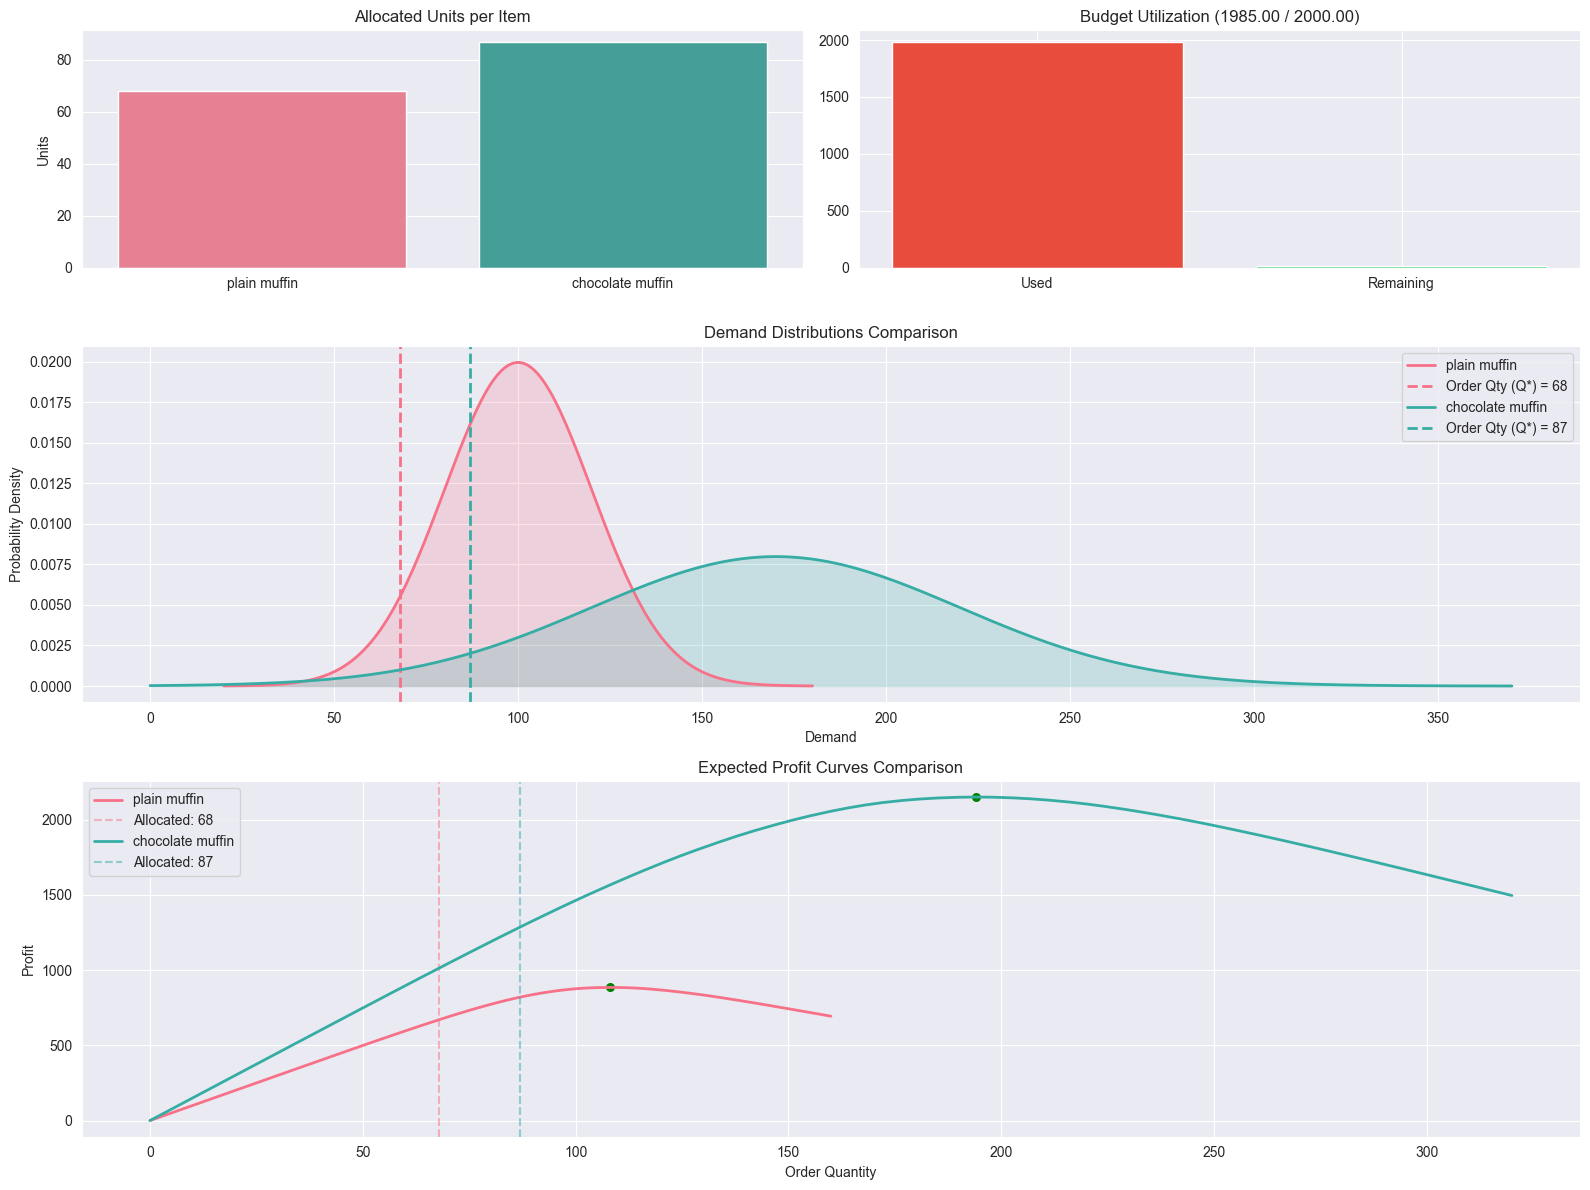

In [1]:
import numpy as np
import xarray as xr

from optistock.items import Item
from optistock.distributions.demand_distributions import NormalDemand
from optistock.solvers import ForecastSolver
from optistock.plot_suite.portfolio import plot_multi_item_allocation


class DistributionForecaster:
    """
    Thin adapter that wraps a DemandDistribution for use with ForecastSolver.

    ForecastSolver expects each forecaster to expose `get_demand_distribution`,
    which returns a dataset of demand samples (e.g. from a Bayesian posterior).
    This adapter generates those samples via Monte Carlo draws from any
    DemandDistribution, making it easy to try the solver before fitting a full
    Bayesian model.
    """

    def __init__(self, distribution, n_samples: int = 2000):
        self.distribution = distribution
        self.n_samples = n_samples

    def get_demand_distribution(self, start_date, end_date):
        samples = np.maximum(
            0,
            np.random.normal(
                self.distribution.mean, self.distribution.std, self.n_samples
            ),
        )
        return xr.Dataset({"demand": ("sample", samples)})


# ── Item definitions ──────────────────────────────────────────────────────────
# `constraints={"cost": <value>}` declares the per-unit resource consumption.
# The key "cost" must match a key in ForecastSolver(limits=...).
plain_muffin = Item(
    "plain muffin",
    cost_price=10,
    selling_price=20,
    salvage_value=5,
    constraints={"cost": 10},
)
chocolate_muffin = Item(
    "chocolate muffin",
    cost_price=15,
    selling_price=30,
    salvage_value=8,
    constraints={"cost": 15},
)

# ── Demand distributions ──────────────────────────────────────────────────────
plain_demand     = NormalDemand(100, 20)
chocolate_demand = NormalDemand(170, 50)

# ── Solve ─────────────────────────────────────────────────────────────────────
BUDGET = 2_000

# ForecastSolver needs forecaster objects; the plotting functions need
# DemandDistribution objects — so we maintain two separate problem lists.
solver_problems = [
    (plain_muffin,     DistributionForecaster(plain_demand)),
    (chocolate_muffin, DistributionForecaster(chocolate_demand)),
]
plot_problems = [
    (plain_muffin,     plain_demand),
    (chocolate_muffin, chocolate_demand),
]

solver = ForecastSolver(solver_problems, limits={"cost": BUDGET})
allocation = solver.solve("2025-01-01", "2025-01-02")

print("Optimal allocation:", allocation)
fig = plot_multi_item_allocation(allocation, plot_problems, budget=BUDGET)

## Multiple Constraints

Most real-world problems involve several simultaneous constraints. Our bakery faces both:

- A **budget** constraint: total ingredient spend ≤ £2,000  
- A **storage** constraint: total shelf space used ≤ 1,000 units

Each item declares its consumption of *every* shared resource in its `constraints` dict. The solver enforces all limits jointly using linear constraint matrices.

### Shadow prices (Lagrangian multipliers)

When `ForecastSolver` runs the trust-region solver it also computes **shadow prices** — the marginal value of relaxing each constraint by one unit.

| Shadow price | Interpretation |
|---|---|
| High | This constraint is actively limiting profit; relaxing it is valuable |
| Near zero | The constraint is slack (not binding); relaxing it won't help |

Shadow prices are available in `solver.shadow_prices` after calling `solve()`.

Optimal allocation: {'plain muffin': 60, 'chocolate muffin': 93}
Shadow prices:      {'cost': 0.958157064455879, 'storage': 2.9713132272985727e-08}


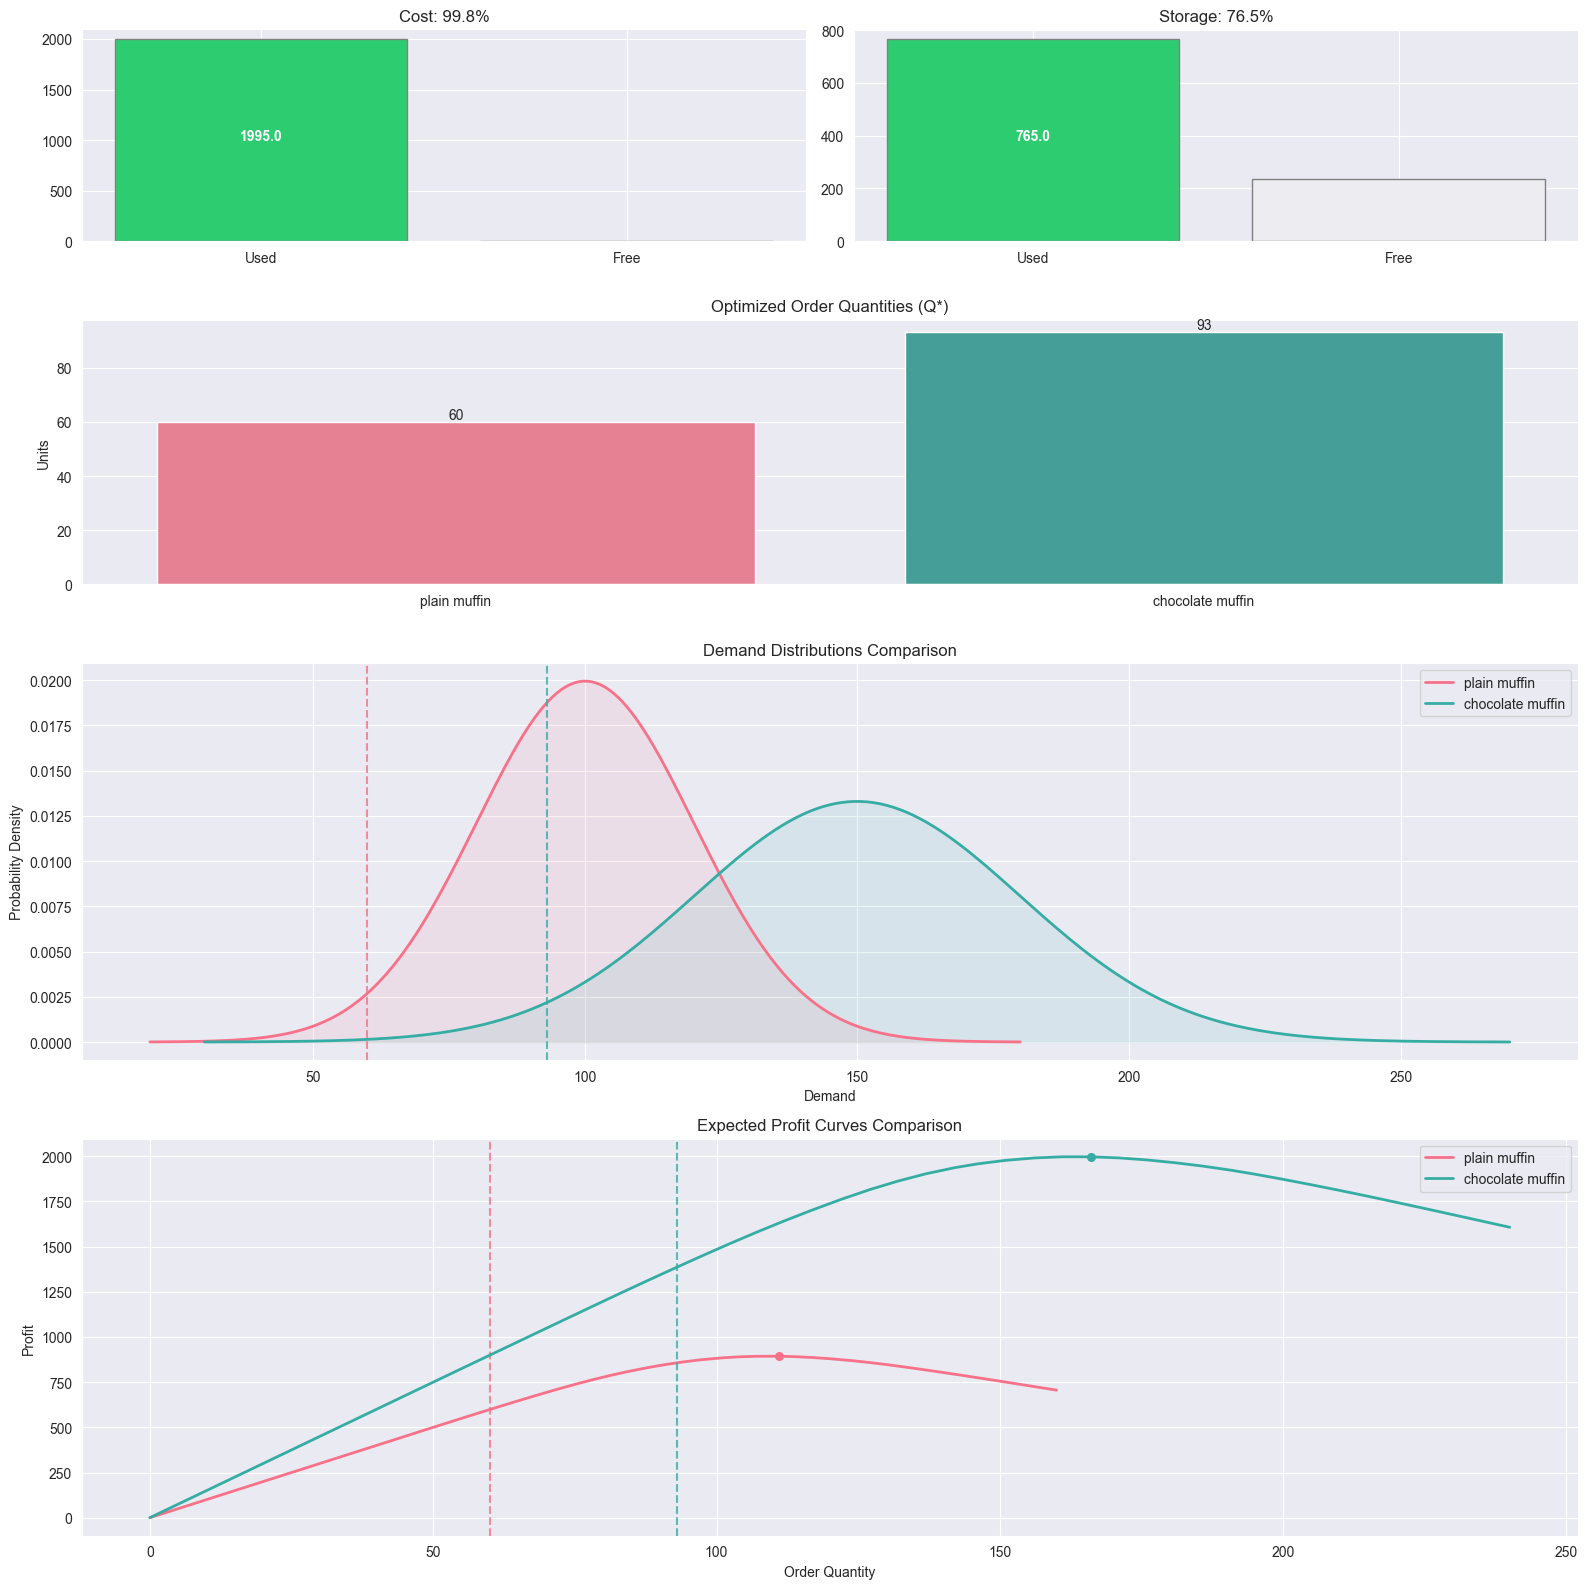

In [2]:
from optistock.plot_suite.portfolio import plot_constrained_allocation

# ── Re-define items with both cost and storage constraints ────────────────────
plain_muffin = Item(
    "plain muffin",
    cost_price=10,
    selling_price=20,
    salvage_value=5,
    constraints={"cost": 10, "storage": 5},   # uses 5 storage units each
)
chocolate_muffin = Item(
    "chocolate muffin",
    cost_price=15,
    selling_price=30,
    salvage_value=8,
    constraints={"cost": 15, "storage": 5},   # uses 5 storage units each
)

plain_demand     = NormalDemand(100, 20)
chocolate_demand = NormalDemand(150, 30)

LIMITS = {"cost": 2_000, "storage": 1_000}

solver_problems = [
    (plain_muffin,     DistributionForecaster(plain_demand)),
    (chocolate_muffin, DistributionForecaster(chocolate_demand)),
]
plot_problems = [
    (plain_muffin,     plain_demand),
    (chocolate_muffin, chocolate_demand),
]

solver = ForecastSolver(solver_problems, limits=LIMITS)
allocation = solver.solve("2025-01-01", "2025-01-02")

print("Optimal allocation:", allocation)
print("Shadow prices:     ", solver.shadow_prices)
fig = plot_constrained_allocation(allocation, plot_problems, LIMITS)

## Optimization Summary

The summary plot shows two things:

1. **Constraint impact** — how much profit was sacrificed vs. the unconstrained optimum. "Potential" is what each item could earn if ordered freely; "Realized" is the constrained profit.

2. **Shadow prices** — which constraints are most costly. A high shadow price means every extra unit of that resource (£1 more budget, 1 more storage slot) translates directly into additional profit — a direct guide for capacity investment decisions.

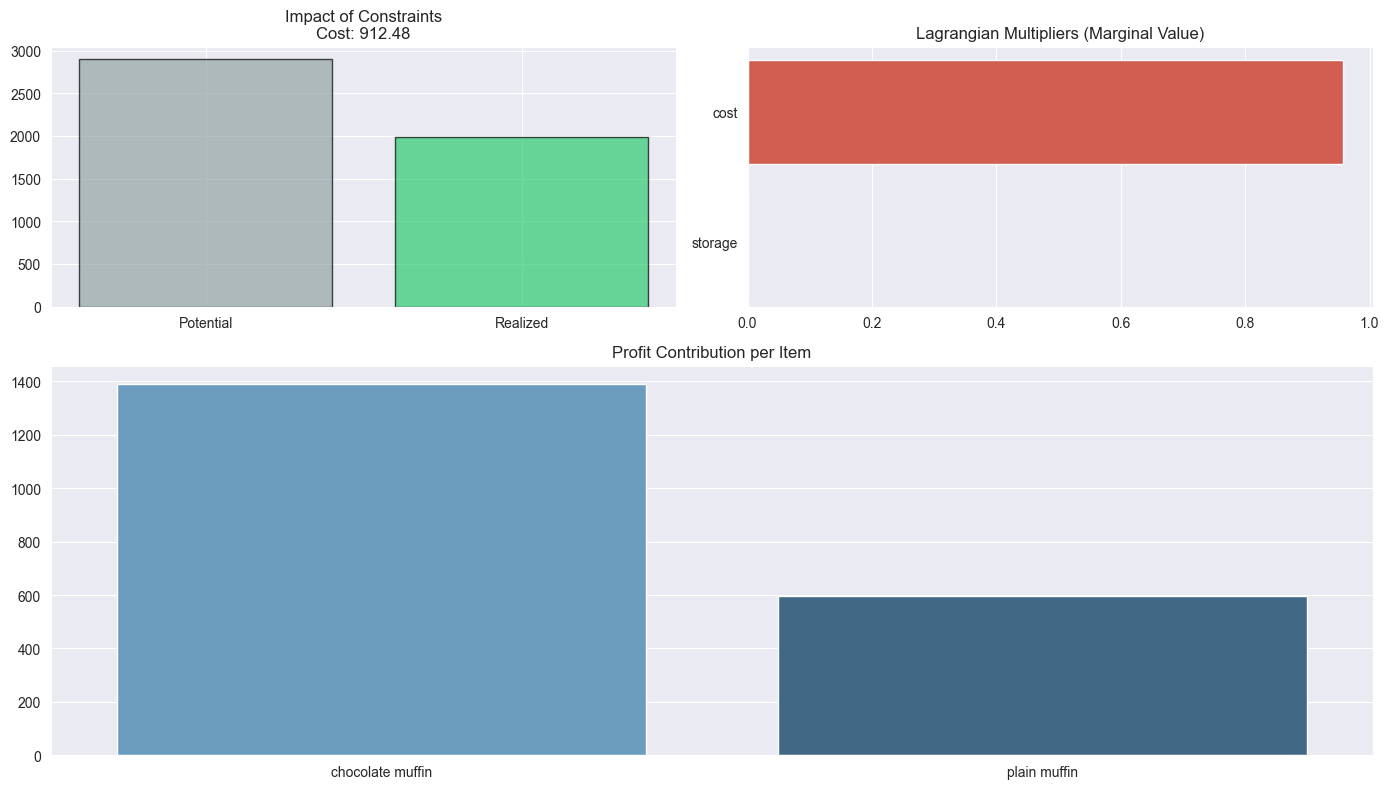

In [3]:
from optistock.plot_suite.portfolio import plot_optimization_summary

# shadow_prices is populated by solve() when the trust-region solver is used
fig = plot_optimization_summary(allocation, plot_problems, solver.shadow_prices)

### Reading the results

- **Constraint cost** (top-left): the gap between potential and realized profit is the "price" you pay for your constraints. If it is large relative to the resource cost, investing in more capacity has a clear financial justification.

- **Lagrangian multipliers** (top-right): a shadow price of, say, £0.80 on the budget means that relaxing the budget by £1 is expected to increase profit by £0.80. Compare this directly against the cost of acquiring that resource.

- **Per-item profit contribution** (bottom): shows whether the allocation is balanced or if one item dominates. An item with near-zero realized profit may not be worth stocking under tight constraints.